# 🫐 Heart Disease Risk Prediction 2026

Notebook ini berisi pipeline lengkap prediksi risiko penyakit jantung menggunakan dataset `heart_disease_risk_2026.csv`.

**Langkah-langkah:**
1. Import Library
2. Load & Eksplorasi Data (EDA)
3. Preprocessing (Encoding, Scaling, Split)
4. Training 3 Model (Logistic Regression, Random Forest, XGBoost)
5. Evaluasi & Perbandingan Model
6. Feature Importance
7. Inference - Prediksi Data Pasien Baru
8. Simpan Knowledge Model

## 1. Import Library

In [1]:
# Standard Library
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Wedge

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluasi
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

# Config Visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Semua library berhasil di-import!')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

Semua library berhasil di-import!
   NumPy  : 2.5.1
   Pandas : 3.0.5


## 2. Load & Eksplorasi Data (EDA)

In [2]:
# Load Dataset
df = pd.read_csv('heart_disease_risk_2026.csv')
df.drop(columns=['patient_id'], inplace=True)

print('=' * 60)
print('INFORMASI DATASET')
print('=' * 60)
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Missing values : {df.isnull().sum().sum()}')
print()
df.head()

INFORMASI DATASET
Jumlah baris   : 9,000
Jumlah kolom   : 26
Missing values : 0



,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,44,Male,117,74,193,57,106,119,112,5.2,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,57,Male,139,94,185,69,110,35,114,5.9,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,29,Male,128,78,197,52,108,157,95,5.5,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,72,Male,132,86,197,59,104,143,92,4.8,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,62,Female,116,75,154,65,75,104,135,6.2,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


In [3]:
print('INFO KOLOM')
print('-' * 60)
df.info()

INFO KOLOM
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        9000 non-null   int64  
 1   sex                        9000 non-null   str    
 2   resting_bp_systolic        9000 non-null   int64  
 3   resting_bp_diastolic       9000 non-null   int64  
 4   cholesterol_total          9000 non-null   int64  
 5   hdl                        9000 non-null   int64  
 6   ldl                        9000 non-null   int64  
 7   triglycerides              9000 non-null   int64  
 8   fasting_blood_sugar        9000 non-null   int64  
 9   hba1c                      9000 non-null   float64
 10  bmi                        9000 non-null   float64
 11  resting_heart_rate         9000 non-null   int64  
 12  max_heart_rate_achieved    9000 non-null   

In [4]:
print('STATISTIK DESKRIPTIF (Numerik)')
df.describe().T.style.background_gradient(cmap='Blues')

STATISTIK DESKRIPTIF (Numerik)


,count,mean,std,min,25%,50%,75%,max
age,9000.000000,53.977333,13.008051,18.000000,45.000000,54.000000,63.000000,90.000000
resting_bp_systolic,9000.000000,127.849778,13.767233,85.000000,119.000000,128.000000,137.000000,181.000000
resting_bp_diastolic,9000.000000,80.788778,10.939943,50.000000,74.000000,81.000000,88.000000,126.000000
cholesterol_total,9000.000000,188.753556,32.271644,90.000000,167.000000,189.000000,211.000000,314.000000
hdl,9000.000000,55.215333,12.394400,18.000000,47.000000,55.000000,64.000000,110.000000
ldl,9000.000000,103.275556,27.342198,35.000000,85.000000,103.000000,122.000000,207.000000
triglycerides,9000.000000,152.045000,51.448384,35.000000,117.000000,151.000000,186.000000,390.000000
fasting_blood_sugar,9000.000000,119.470444,22.778082,60.000000,104.000000,119.000000,135.000000,204.000000
hba1c,9000.000000,5.791633,0.692645,4.000000,5.300000,5.800000,6.300000,8.600000
bmi,9000.000000,25.264922,4.371525,15.000000,22.300000,25.300000,28.200000,43.300000


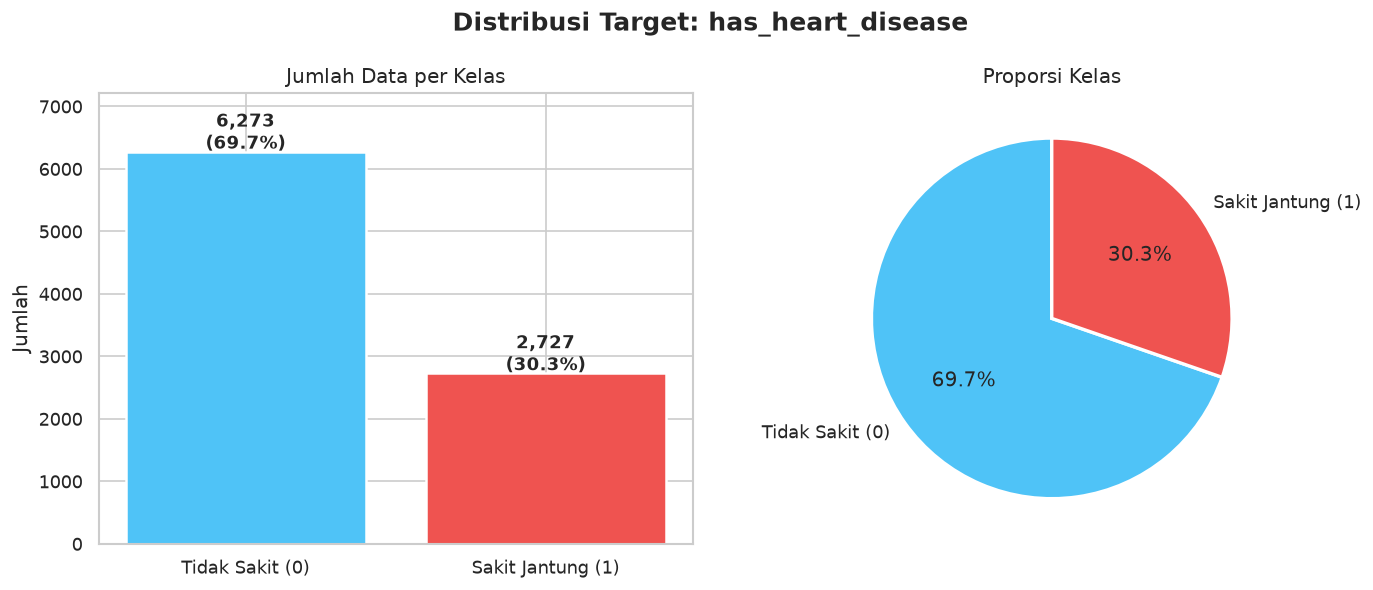

Rasio Imbalance: 69.7% vs 30.3%


In [5]:
# Distribusi Target
target_counts = df['has_heart_disease'].value_counts()
target_pct    = df['has_heart_disease'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Target: has_heart_disease', fontsize=15, fontweight='bold')

colors = ['#4FC3F7', '#EF5350']
labels = ['Tidak Sakit (0)', 'Sakit Jantung (1)']

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 50, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Jumlah Data per Kelas')
axes[0].set_ylabel('Jumlah')
axes[0].set_ylim(0, target_counts.max() * 1.15)

axes[1].pie(
    target_counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()
print(f'Rasio Imbalance: {target_pct[0]:.1f}% vs {target_pct[1]:.1f}%')

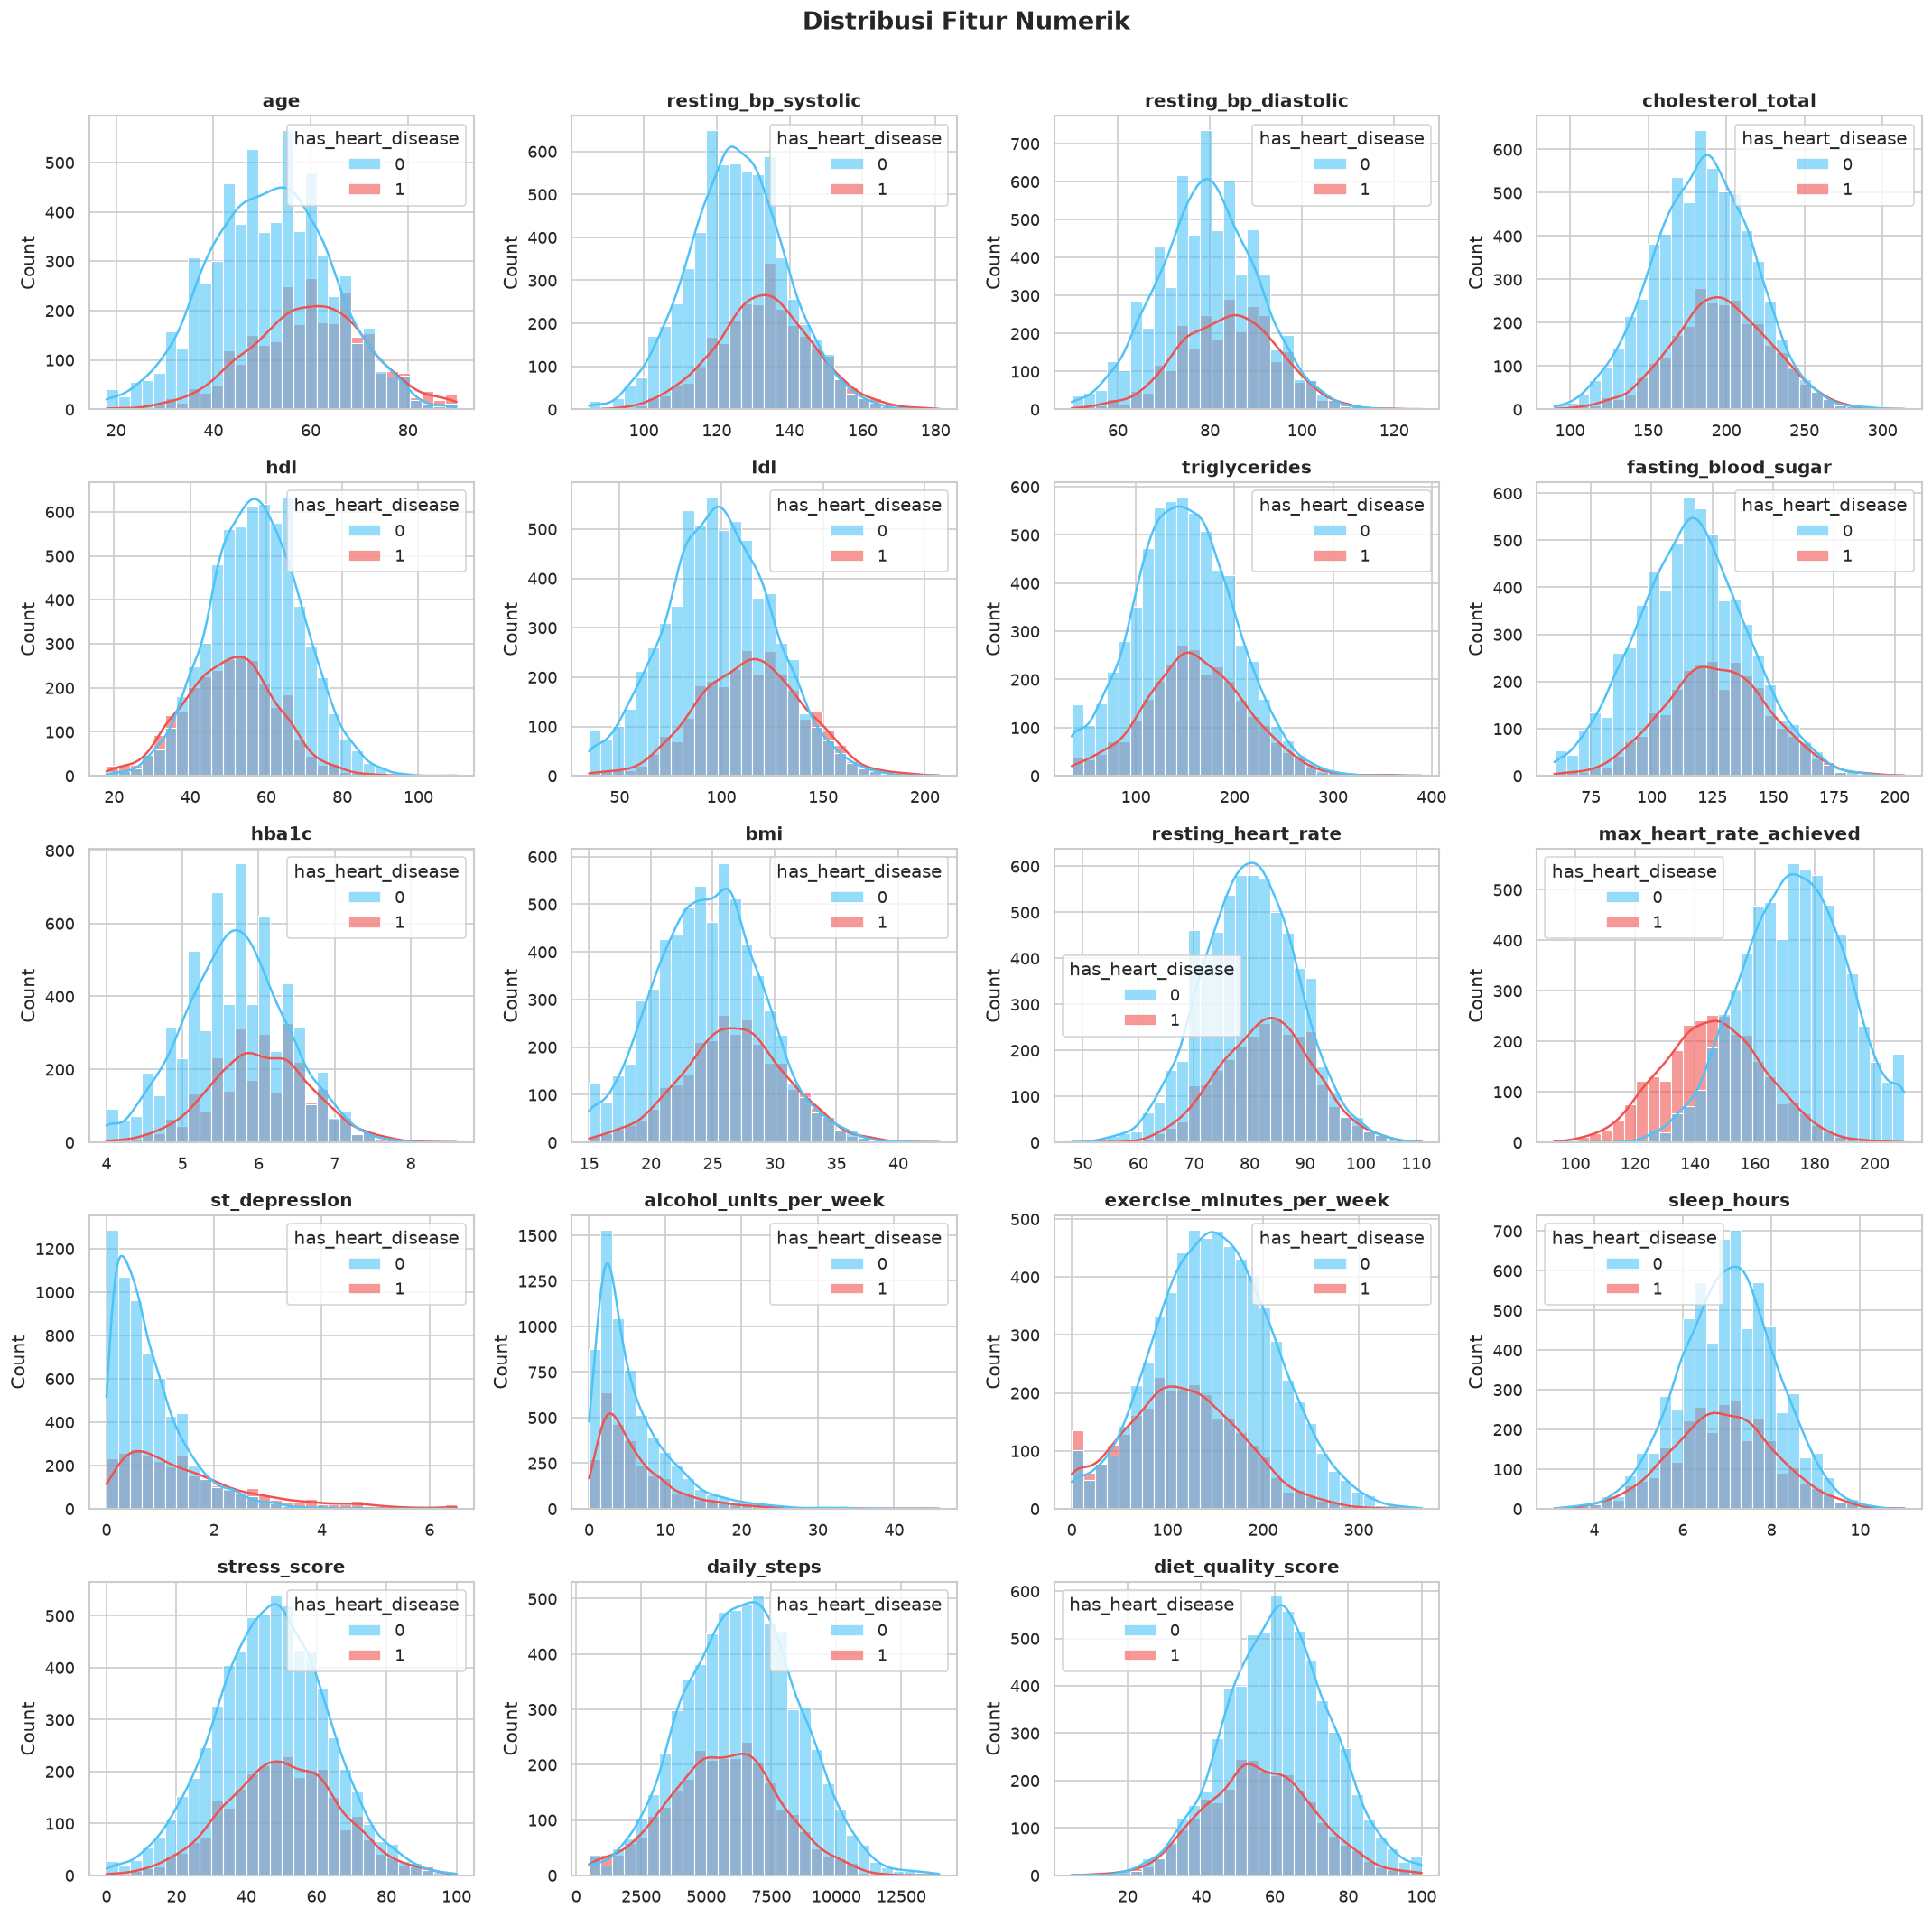

In [6]:
# Distribusi Fitur Numerik
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'has_heart_disease']

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
fig.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df, x=col, hue='has_heart_disease',
        kde=True, ax=axes[i], palette={0: '#4FC3F7', 1: '#EF5350'},
        alpha=0.6, bins=30
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Kolom Kategorikal: ['sex', 'chest_pain_type', 'exercise_induced_angina', 'family_history', 'smoker_status', 'wearable_owner']


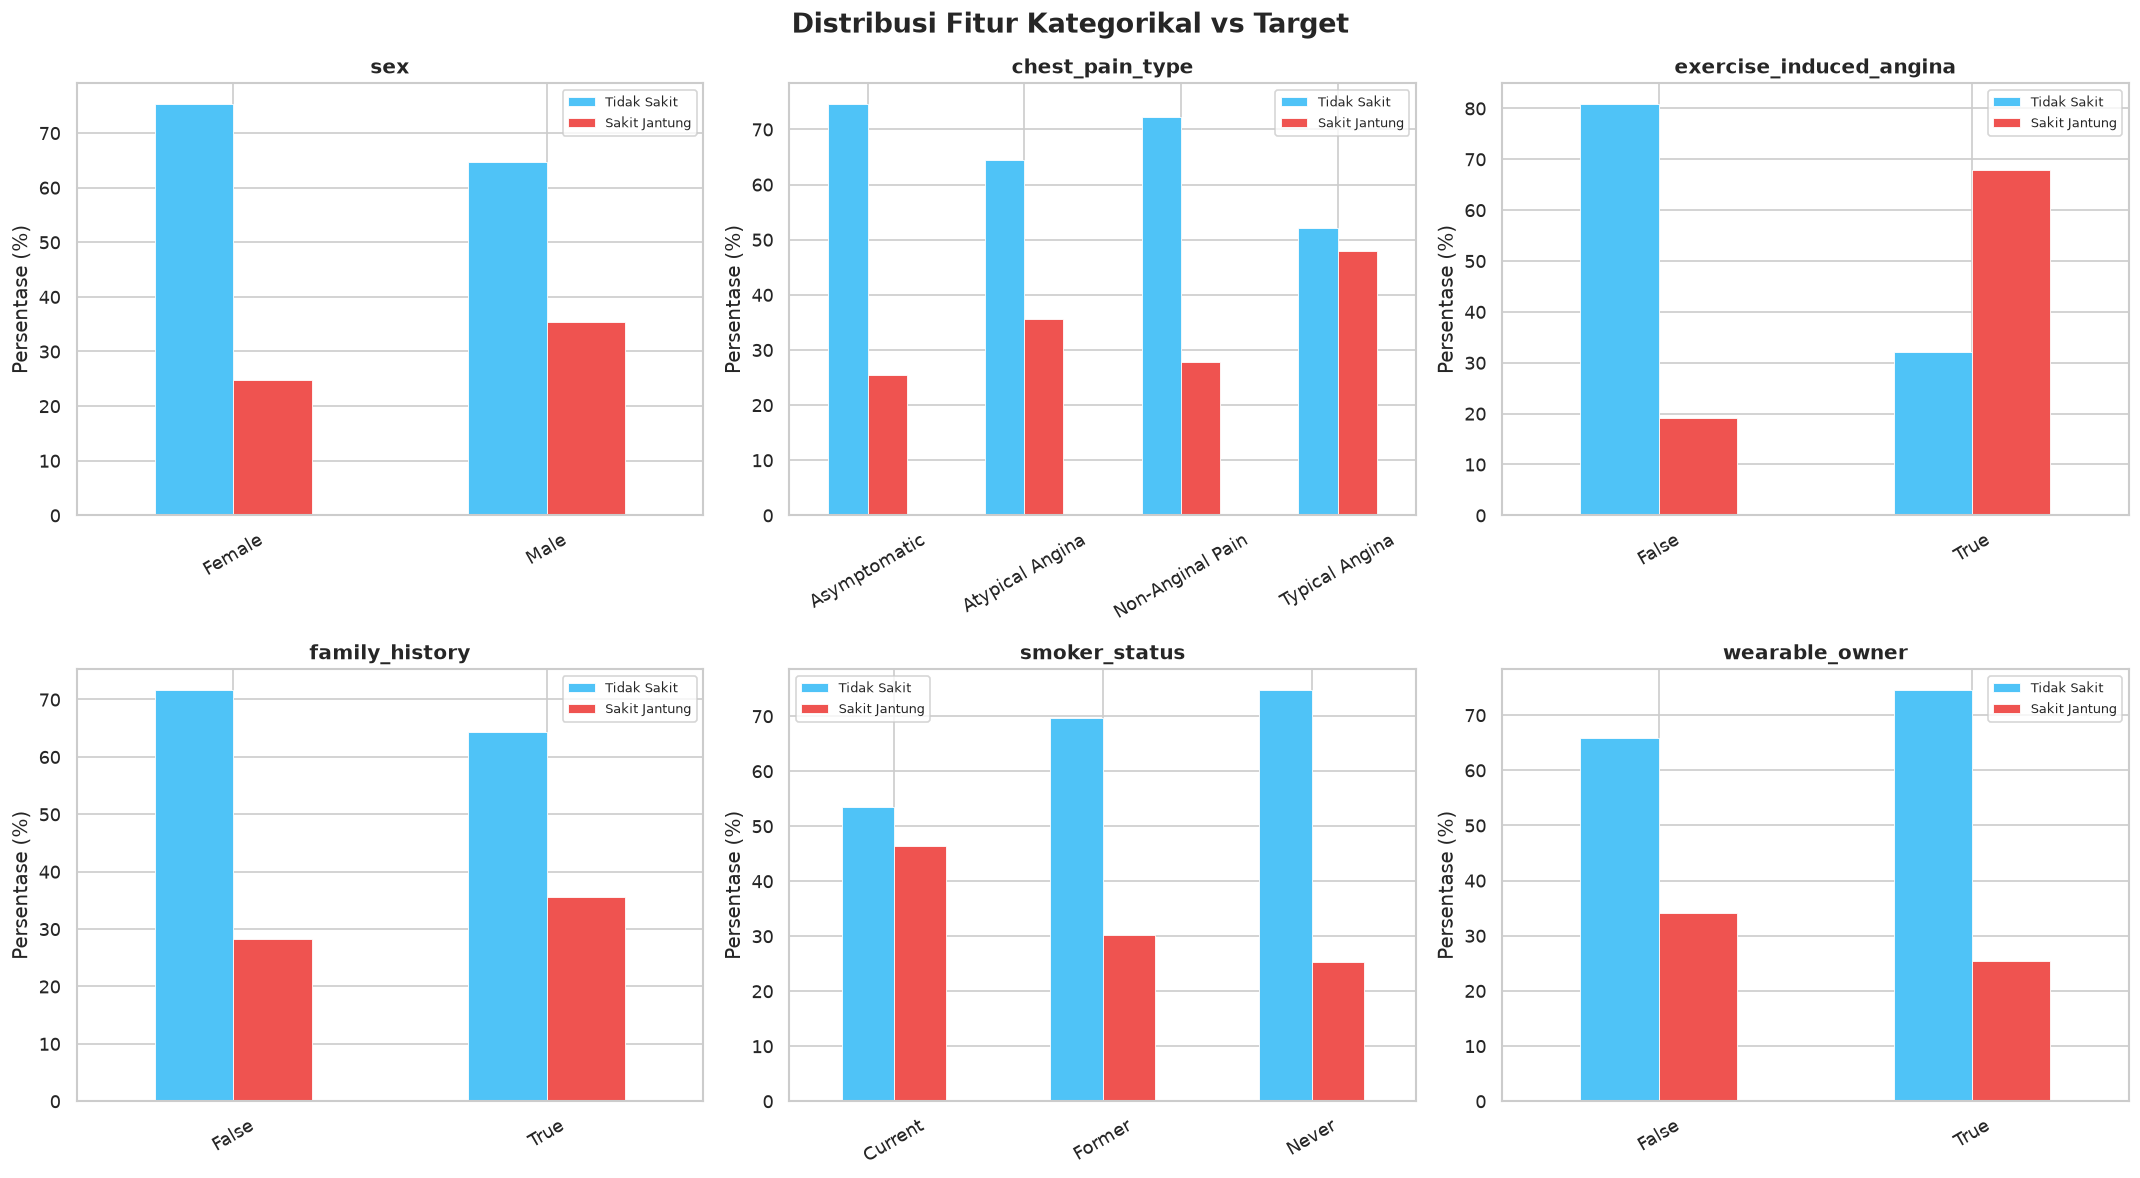

In [7]:
# Distribusi Fitur Kategorikal
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f'Kolom Kategorikal: {cat_cols}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribusi Fitur Kategorikal vs Target', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['has_heart_disease'], normalize='index') * 100
    ct.plot(
        kind='bar', ax=axes[i], color=['#4FC3F7', '#EF5350'],
        edgecolor='white', linewidth=0.5
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Tidak Sakit', 'Sakit Jantung'], fontsize=8)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

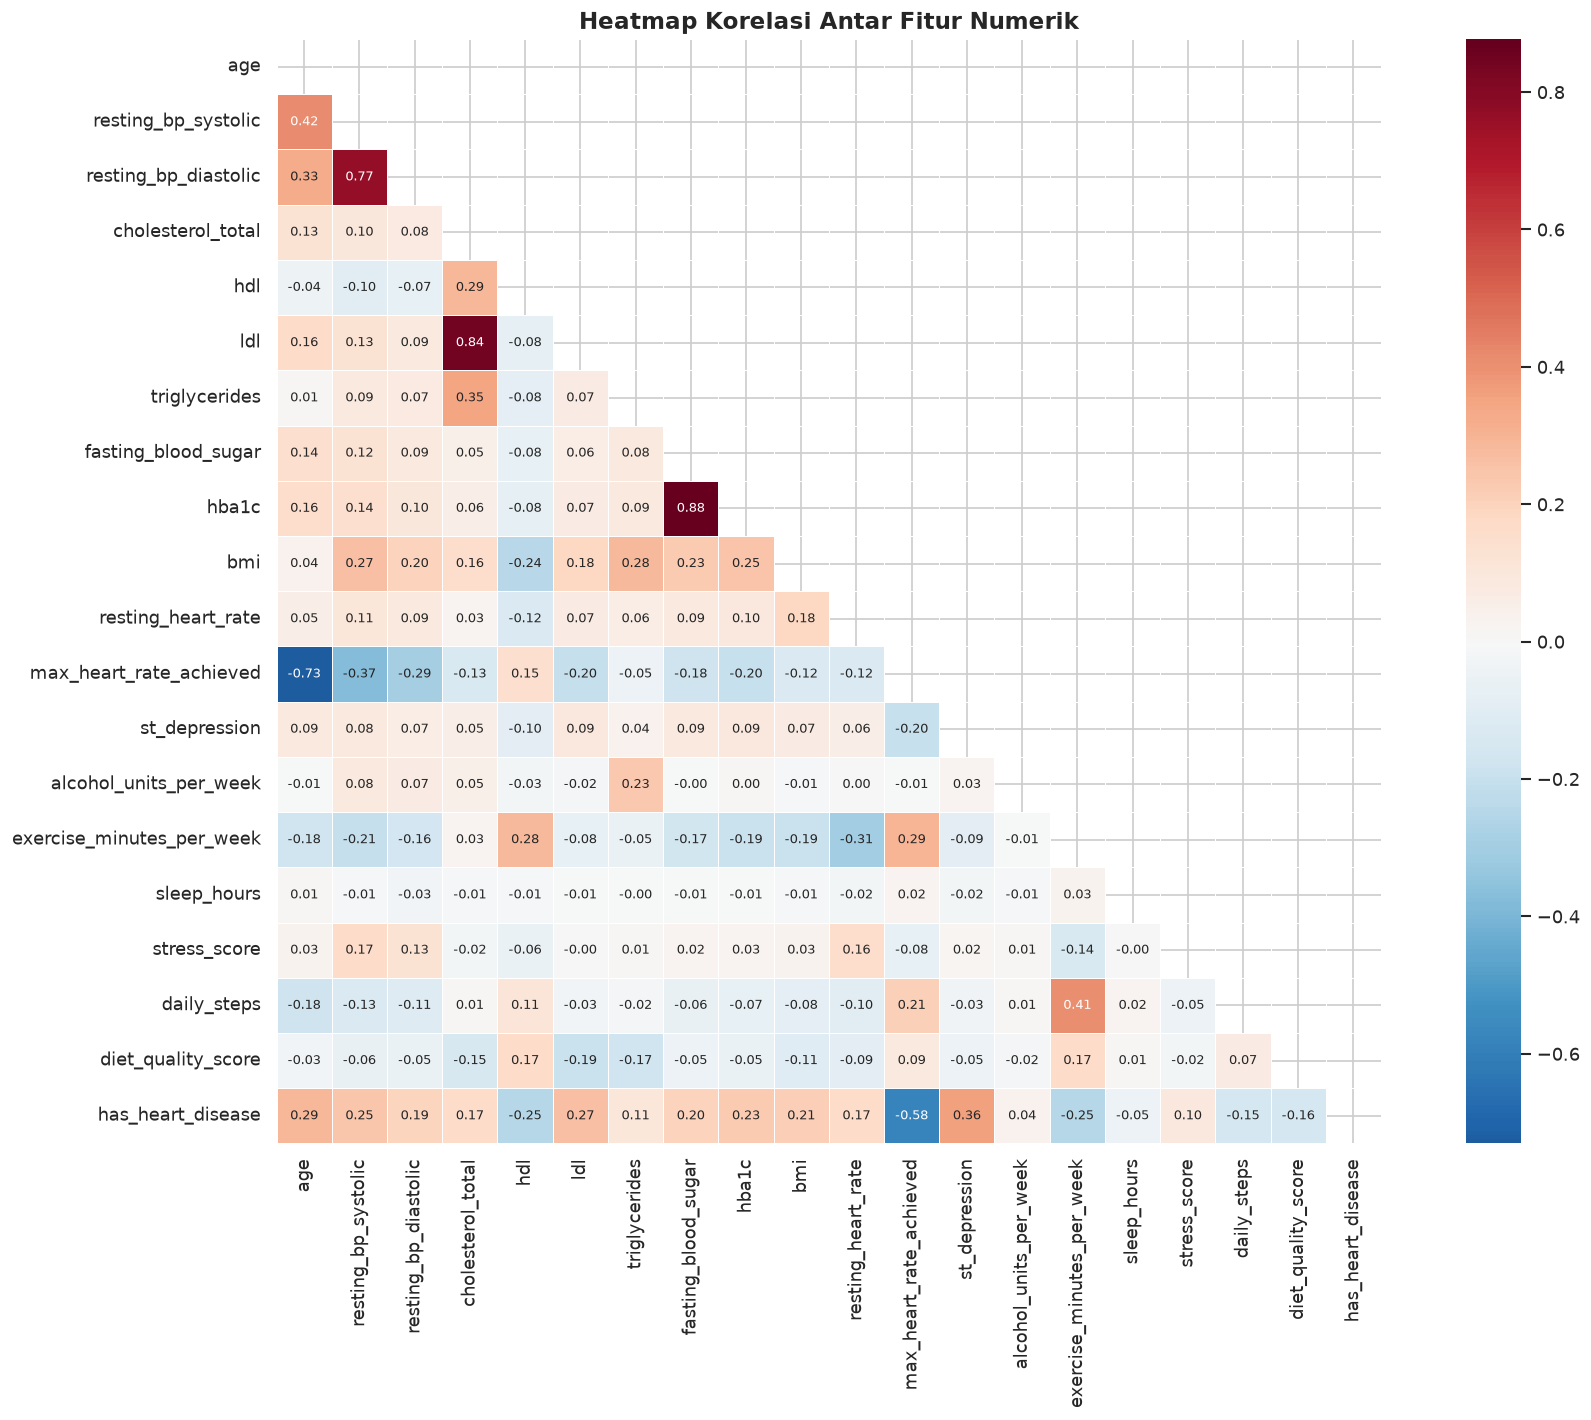

In [8]:
# Heatmap Korelasi
fig, ax = plt.subplots(figsize=(16, 12))
corr = df.select_dtypes(include=['float64', 'int64']).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, ax=ax,
    annot_kws={'size': 8}, linewidths=0.5
)
ax.set_title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [9]:
# Cek Missing Values
missing = df.isnull().sum()
print('Missing Values per Kolom:')
print(missing[missing > 0] if missing.any() else 'Tidak ada missing values!')

Missing Values per Kolom:
Tidak ada missing values!


In [10]:
# Encoding Fitur Kategorikal
df_processed = df.copy()

bool_cols = ['exercise_induced_angina', 'family_history', 'wearable_owner']
for col in bool_cols:
    if df_processed[col].dtype == object:
        df_processed[col] = df_processed[col].map({'True': 1, 'False': 0})
    else:
        df_processed[col] = df_processed[col].astype(int)

le = LabelEncoder()
df_processed['sex'] = le.fit_transform(df_processed['sex'])  # Male=1, Female=0

df_processed = pd.get_dummies(
    df_processed,
    columns=['chest_pain_type', 'smoker_status'],
    drop_first=True
)

print(f'Jumlah fitur setelah encoding: {df_processed.shape[1] - 1}')
print(f'Kolom: {df_processed.columns.tolist()}')

Jumlah fitur setelah encoding: 28
Kolom: ['age', 'sex', 'resting_bp_systolic', 'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl', 'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate', 'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression', 'family_history', 'alcohol_units_per_week', 'exercise_minutes_per_week', 'sleep_hours', 'stress_score', 'wearable_owner', 'daily_steps', 'diet_quality_score', 'has_heart_disease', 'chest_pain_type_Atypical Angina', 'chest_pain_type_Non-Anginal Pain', 'chest_pain_type_Typical Angina', 'smoker_status_Former', 'smoker_status_Never']


In [11]:
X = df_processed.drop(columns=['has_heart_disease'])
y = df_processed['has_heart_disease']

print(f'Shape X : {X.shape}')
print(f'Shape y : {y.shape}')
print(f'Distribusi y : {dict(y.value_counts())}')

Shape X : (9000, 28)
Shape y : (9000,)
Distribusi y : {0: np.int64(6273), 1: np.int64(2727)}


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=' * 50)
print('HASIL SPLIT DATA')
print('=' * 50)
print(f'Training set  : {X_train.shape[0]:,} sampel ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Testing set   : {X_test.shape[0]:,} sampel ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'Jumlah fitur  : {X_train.shape[1]}')

HASIL SPLIT DATA
Training set  : 7,200 sampel (80.0%)
Testing set   : 1,800 sampel (20.0%)
Jumlah fitur  : 28


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling selesai!')
print(f'   Mean (train) ~ {X_train_scaled.mean():.4f}  (harusnya ~ 0)')
print(f'   Std  (train) ~ {X_train_scaled.std():.4f}   (harusnya ~ 1)')

Feature scaling selesai!
   Mean (train) ~ 0.0000  (harusnya ~ 0)
   Std  (train) ~ 1.0000   (harusnya ~ 1)


## 4. Training Model

Tiga model yang akan digunakan:
| Model | Keterangan |
|---|---|
| **Logistic Regression** | Model linear, mudah diinterpretasi |
| **Random Forest** | Ensemble pohon keputusan, robust |
| **XGBoost** | Gradient boosting, performa tinggi |

In [14]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=5,
        min_samples_leaf=2, n_jobs=-1, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    )
}

print(f'{len(models)} model siap dilatih.')

3 model siap dilatih.


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('Mulai training...')
print('=' * 60)

for name, model in models.items():
    print(f'\nTraining: {name}')

    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)

    y_pred      = model.predict(X_te)
    y_pred_prob = model.predict_proba(X_te)[:, 1]

    cv_scores = cross_val_score(
        model, X_tr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1
    )

    results[name] = {
        'model'       : model,
        'y_pred'      : y_pred,
        'y_pred_prob' : y_pred_prob,
        'accuracy'    : accuracy_score(y_test, y_pred),
        'precision'   : precision_score(y_test, y_pred, zero_division=0),
        'recall'      : recall_score(y_test, y_pred, zero_division=0),
        'f1'          : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'     : roc_auc_score(y_test, y_pred_prob),
        'cv_mean'     : cv_scores.mean(),
        'cv_std'      : cv_scores.std()
    }

    print(f'   Selesai | Accuracy: {results[name]["accuracy"]:.4f} | ROC-AUC: {results[name]["roc_auc"]:.4f} | CV: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

print('\n' + '=' * 60)
print('Semua model selesai dilatih!')

Mulai training...

Training: Logistic Regression
   Selesai | Accuracy: 0.8972 | ROC-AUC: 0.9497 | CV: 0.9552 +/- 0.0050

Training: Random Forest
   Selesai | Accuracy: 0.8811 | ROC-AUC: 0.9381 | CV: 0.9393 +/- 0.0080

Training: XGBoost
   Selesai | Accuracy: 0.8878 | ROC-AUC: 0.9444 | CV: 0.9480 +/- 0.0057

Semua model selesai dilatih!


## 5. Evaluasi Model

In [16]:
# Tabel Perbandingan Metrik
metrics_df = pd.DataFrame([
    {
        'Model'      : name,
        'Accuracy'   : f"{r['accuracy']:.4f}",
        'Precision'  : f"{r['precision']:.4f}",
        'Recall'     : f"{r['recall']:.4f}",
        'F1-Score'   : f"{r['f1']:.4f}",
        'ROC-AUC'    : f"{r['roc_auc']:.4f}",
        'CV AUC'     : f"{r['cv_mean']:.4f} +/- {r['cv_std']:.4f}"
    }
    for name, r in results.items()
]).set_index('Model')

print('PERBANDINGAN METRIK MODEL')
print('=' * 80)
metrics_df

PERBANDINGAN METRIK MODEL


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV AUC
Model,,,,,,
Logistic Regression,0.8972,0.8614,0.7872,0.8226,0.9497,0.9552 +/- 0.0050
Random Forest,0.8811,0.8606,0.7248,0.7869,0.9381,0.9393 +/- 0.0080
XGBoost,0.8878,0.8536,0.7596,0.8039,0.9444,0.9480 +/- 0.0057


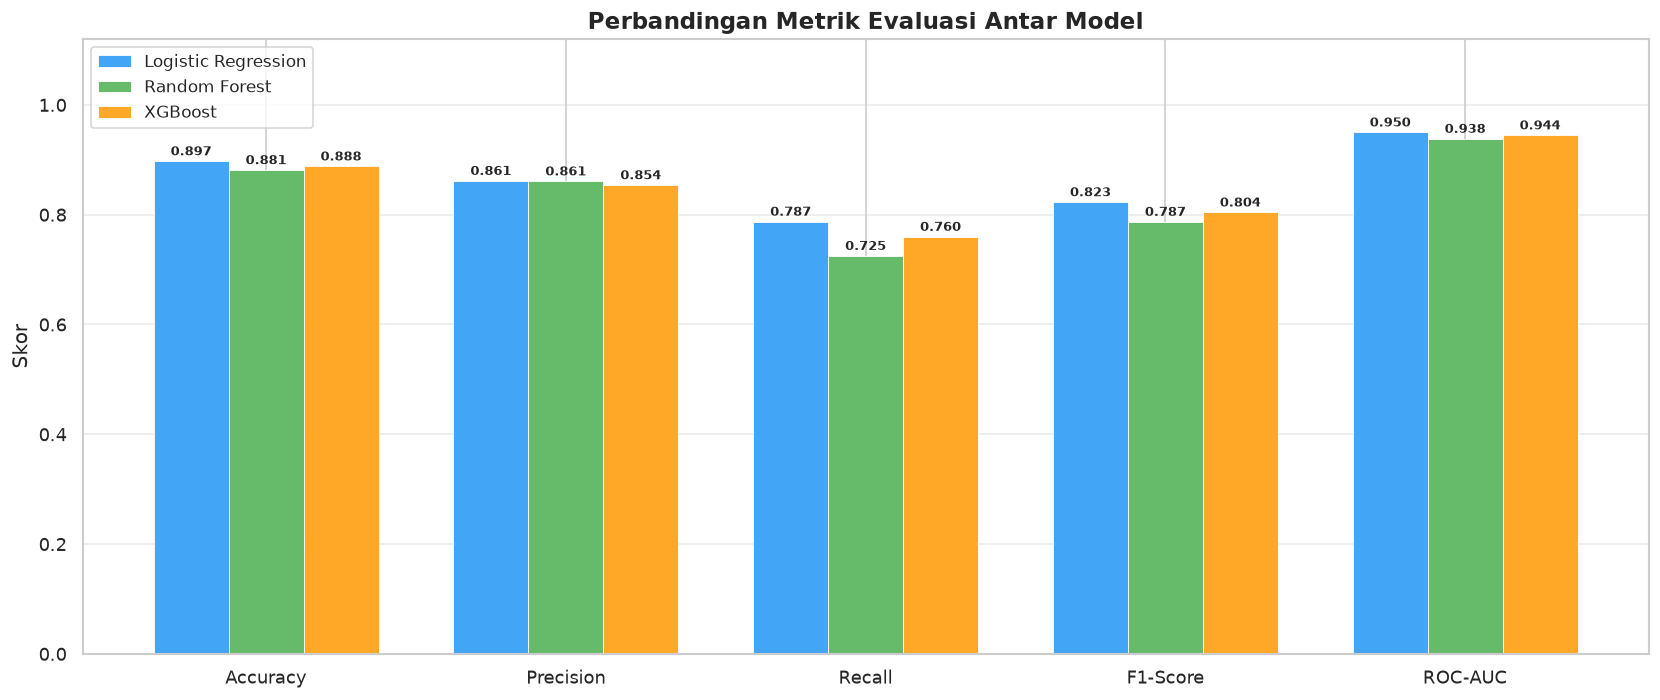

In [17]:
# Bar Chart Metrik
metric_names  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names   = list(results.keys())
colors_model  = ['#42A5F5', '#66BB6A', '#FFA726']

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, color) in enumerate(zip(model_names, colors_model)):
    vals = [results[name][m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Perbandingan Metrik Evaluasi Antar Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Skor')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

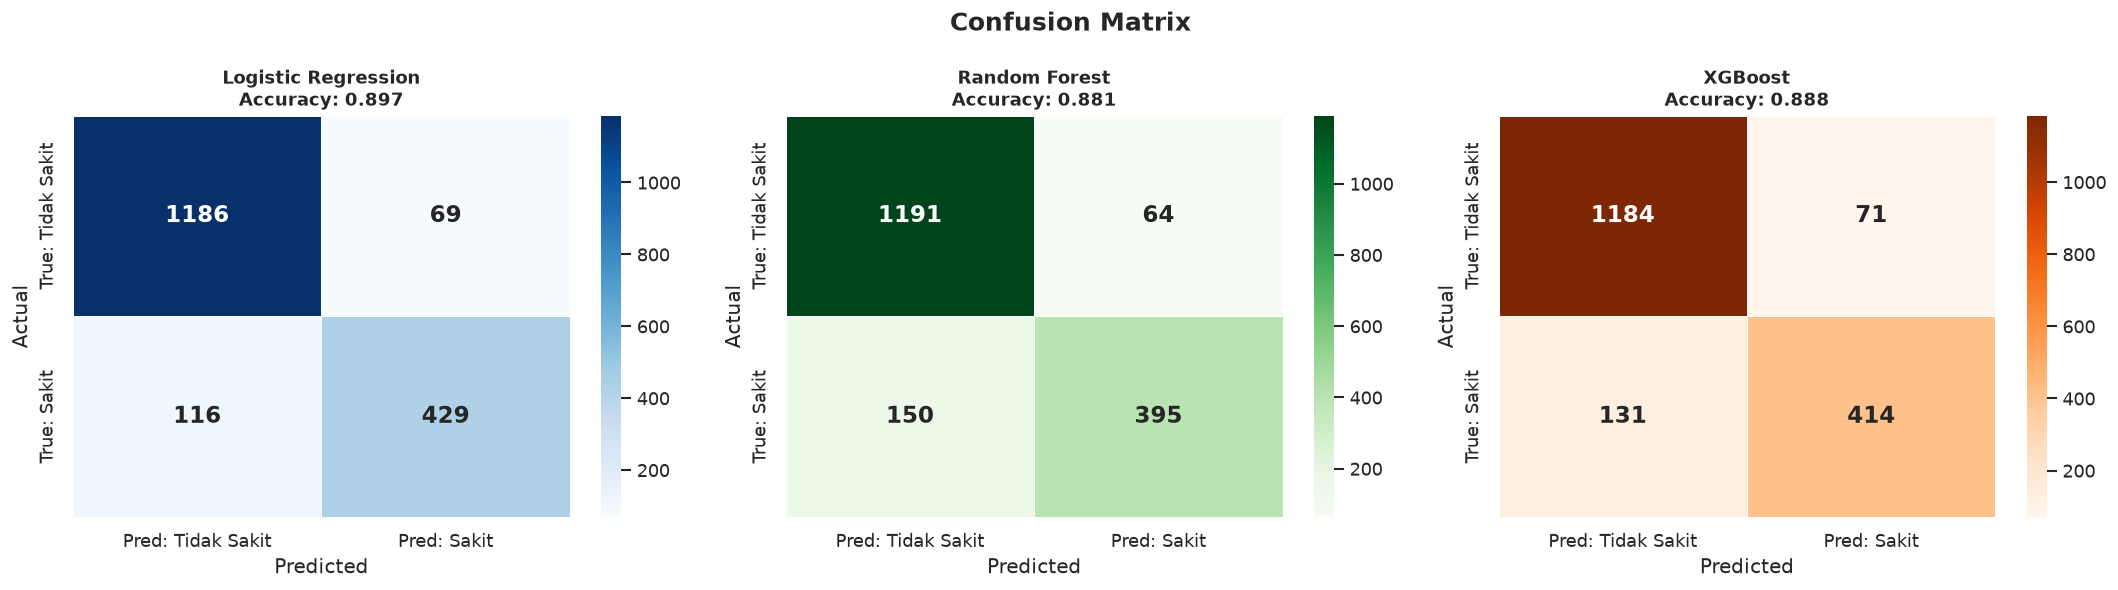

In [18]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix', fontsize=15, fontweight='bold')

for ax, (name, r), color in zip(axes, results.items(), ['Blues', 'Greens', 'Oranges']):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color,
        xticklabels=['Pred: Tidak Sakit', 'Pred: Sakit'],
        yticklabels=['True: Tidak Sakit', 'True: Sakit'],
        ax=ax, linewidths=0.5, linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(
        f'{name}\nAccuracy: {results[name]["accuracy"]:.3f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

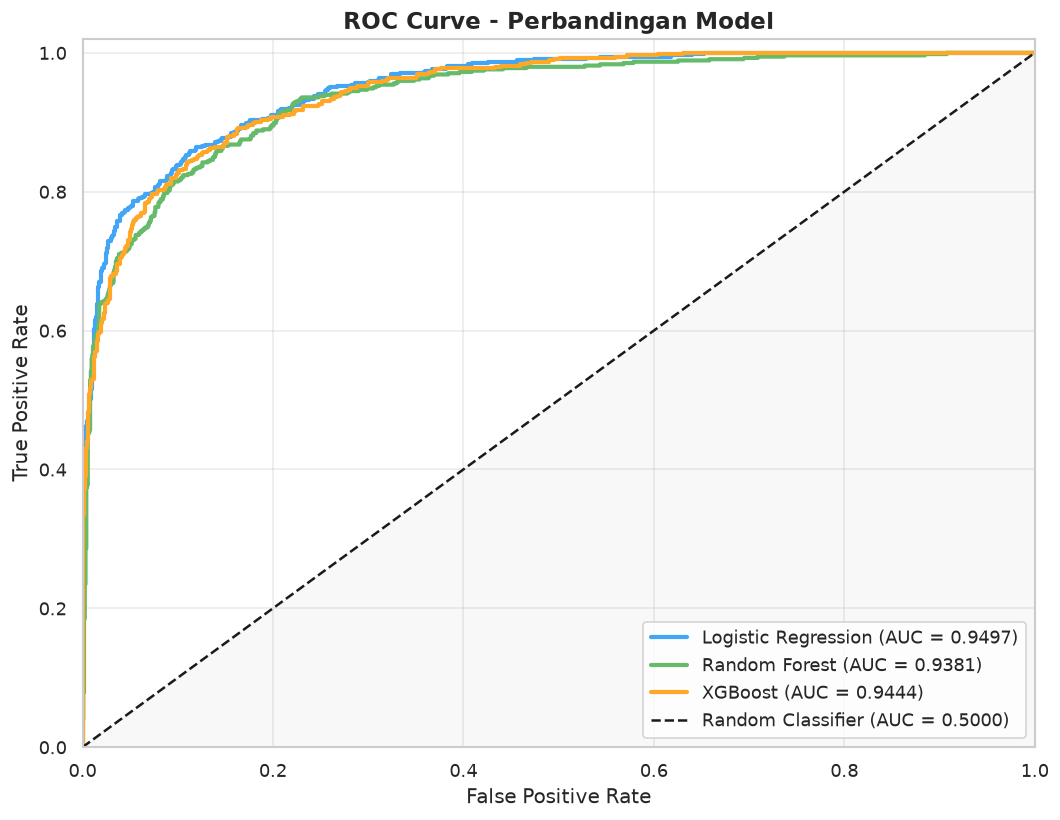

In [19]:
# ROC Curve
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#42A5F5', '#66BB6A', '#FFA726']

for (name, r), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_pred_prob'])
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f"{name} (AUC = {r['roc_auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5000)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Perbandingan Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.4)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

In [20]:
# Classification Report
for name, r in results.items():
    print('=' * 60)
    print(f'Classification Report: {name}')
    print('=' * 60)
    print(classification_report(
        y_test, r['y_pred'],
        target_names=['Tidak Sakit', 'Sakit Jantung']
    ))
    print()

Classification Report: Logistic Regression
               precision    recall  f1-score   support

  Tidak Sakit       0.91      0.95      0.93      1255
Sakit Jantung       0.86      0.79      0.82       545

     accuracy                           0.90      1800
    macro avg       0.89      0.87      0.88      1800
 weighted avg       0.90      0.90      0.90      1800


Classification Report: Random Forest
               precision    recall  f1-score   support

  Tidak Sakit       0.89      0.95      0.92      1255
Sakit Jantung       0.86      0.72      0.79       545

     accuracy                           0.88      1800
    macro avg       0.87      0.84      0.85      1800
 weighted avg       0.88      0.88      0.88      1800


Classification Report: XGBoost
               precision    recall  f1-score   support

  Tidak Sakit       0.90      0.94      0.92      1255
Sakit Jantung       0.85      0.76      0.80       545

     accuracy                           0.89      1800

## 6. Feature Importance

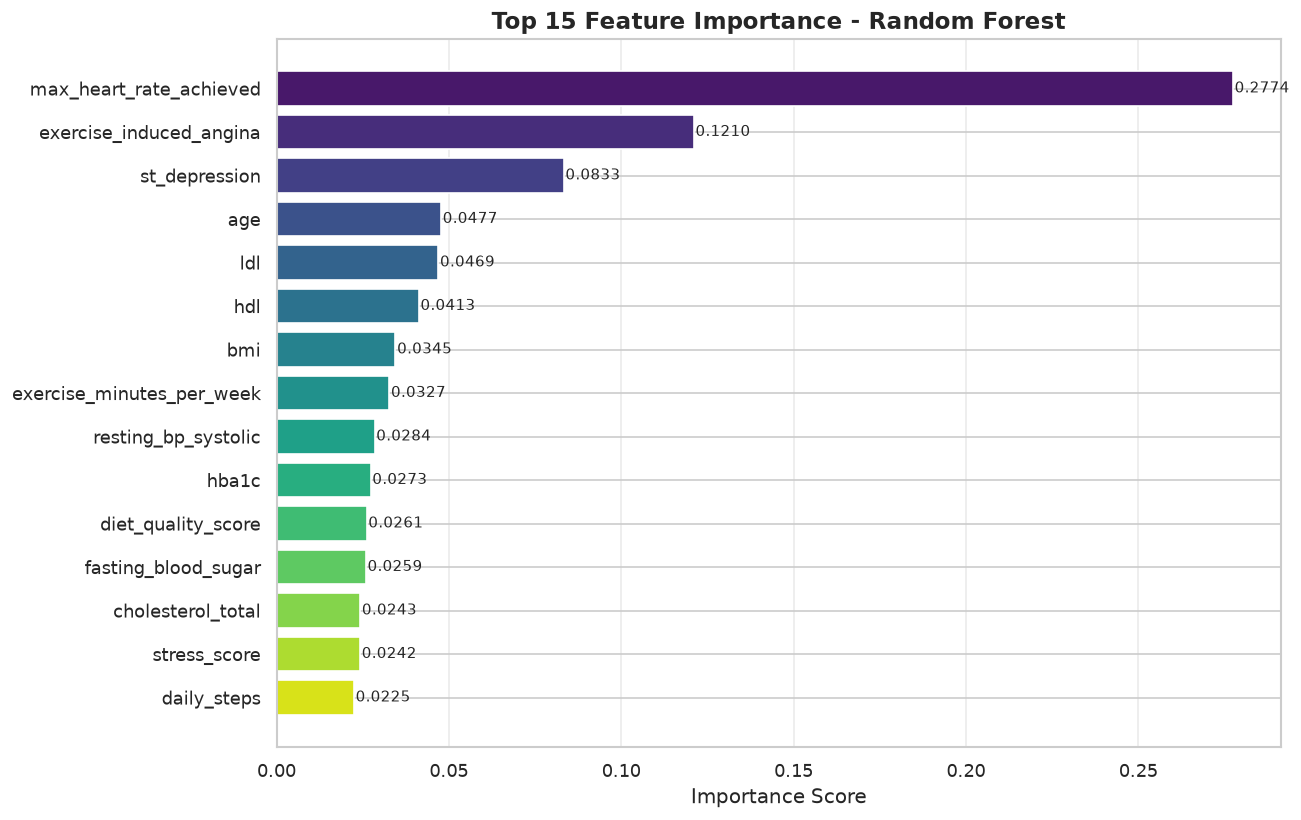

In [21]:
# Feature Importance - Random Forest
rf_model = results['Random Forest']['model']
rf_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_n = 15
fig, ax = plt.subplots(figsize=(11, 7))

colors_imp = sns.color_palette('viridis', top_n)
bars = ax.barh(
    rf_importance['Feature'][:top_n][::-1],
    rf_importance['Importance'][:top_n][::-1],
    color=colors_imp[::-1], edgecolor='white'
)

for bar, v in zip(bars, rf_importance['Importance'][:top_n][::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{v:.4f}', va='center', fontsize=9)

ax.set_title(f'Top {top_n} Feature Importance - Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

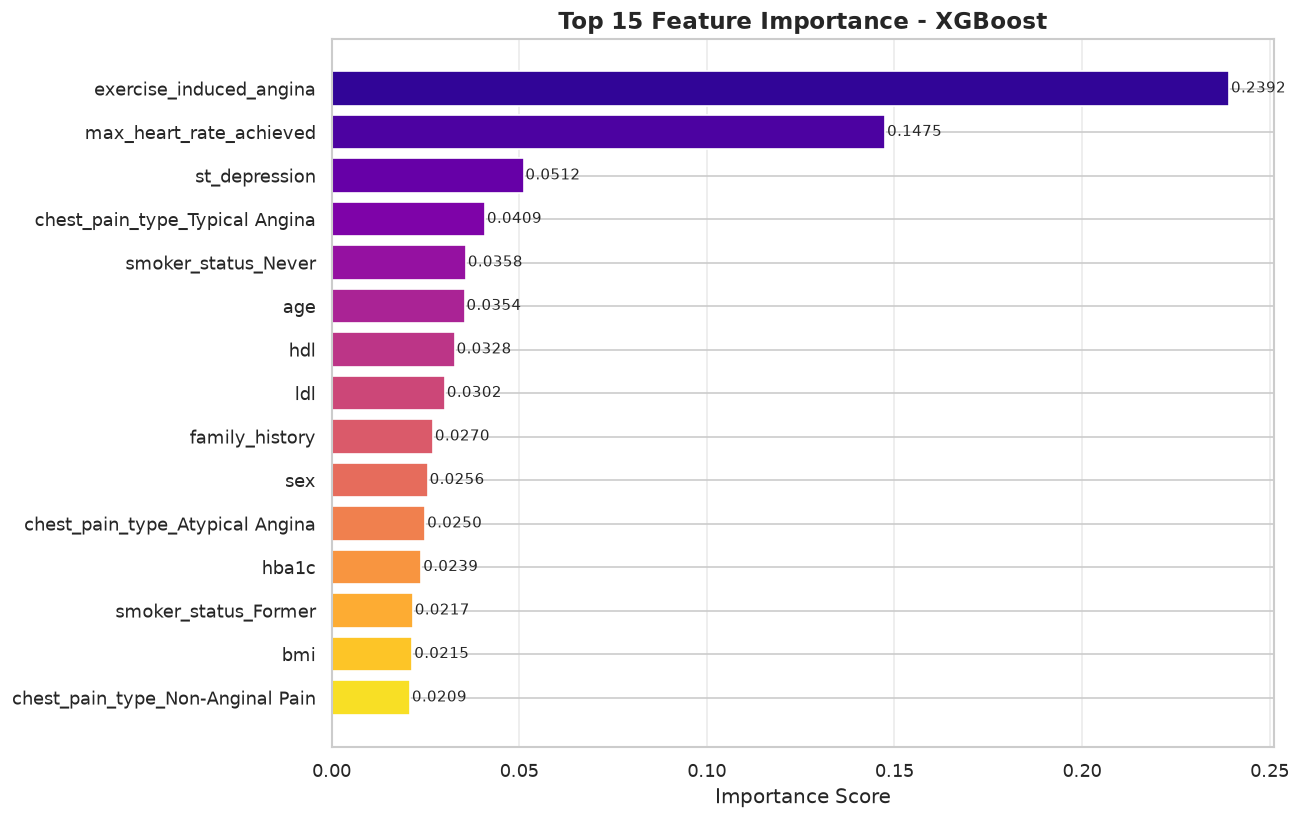

In [22]:
# Feature Importance - XGBoost
xgb_model = results['XGBoost']['model']
xgb_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))
colors_xgb = sns.color_palette('plasma', top_n)

bars = ax.barh(
    xgb_importance['Feature'][:top_n][::-1],
    xgb_importance['Importance'][:top_n][::-1],
    color=colors_xgb[::-1], edgecolor='white'
)

for bar, v in zip(bars, xgb_importance['Importance'][:top_n][::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{v:.4f}', va='center', fontsize=9)

ax.set_title(f'Top {top_n} Feature Importance - XGBoost', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

In [23]:
# Ringkasan Final
best_model = max(results, key=lambda n: results[n]['roc_auc'])

print('=' * 60)
print('RINGKASAN EVALUASI MODEL')
print('=' * 60)
for name, r in results.items():
    marker = '(Best)' if name == best_model else '      '
    print(f"{marker} {name:<25} | ROC-AUC: {r['roc_auc']:.4f} | F1: {r['f1']:.4f} | Acc: {r['accuracy']:.4f}")

print('=' * 60)
print(f'Model Terbaik (ROC-AUC): {best_model}')
print(f'   ROC-AUC  : {results[best_model]["roc_auc"]:.4f}')
print(f'   Accuracy : {results[best_model]["accuracy"]:.4f}')
print(f'   F1-Score : {results[best_model]["f1"]:.4f}')
print('=' * 60)

RINGKASAN EVALUASI MODEL
(Best) Logistic Regression       | ROC-AUC: 0.9497 | F1: 0.8226 | Acc: 0.8972
       Random Forest             | ROC-AUC: 0.9381 | F1: 0.7869 | Acc: 0.8811
       XGBoost                   | ROC-AUC: 0.9444 | F1: 0.8039 | Acc: 0.8878
Model Terbaik (ROC-AUC): Logistic Regression
   ROC-AUC  : 0.9497
   Accuracy : 0.8972
   F1-Score : 0.8226


## 7. Inference - Prediksi dari Data Pasien Baru

Masukkan data pasien baru pada dictionary `data_pasien_baru` di cell berikutnya, lalu jalankan semua cell di bawah untuk mendapatkan prediksi dari ketiga model.

### Panduan Nilai yang Valid
| Kolom | Tipe | Contoh / Nilai Valid |
|---|---|---|
| `age` | int | `45` |
| `sex` | str | `'Male'` atau `'Female'` |
| `resting_bp_systolic` | int | `120` |
| `resting_bp_diastolic` | int | `80` |
| `cholesterol_total` | int | `200` |
| `hdl` | int | `55` |
| `ldl` | int | `110` |
| `triglycerides` | int | `150` |
| `fasting_blood_sugar` | int | `100` |
| `hba1c` | float | `5.5` |
| `bmi` | float | `24.0` |
| `resting_heart_rate` | int | `72` |
| `max_heart_rate_achieved` | int | `160` |
| `chest_pain_type` | str | `'Asymptomatic'` / `'Atypical Angina'` / `'Non-Anginal Pain'` / `'Typical Angina'` |
| `exercise_induced_angina` | bool | `True` atau `False` |
| `st_depression` | float | `1.0` |
| `family_history` | bool | `True` atau `False` |
| `smoker_status` | str | `'Never'` / `'Former'` / `'Current'` |
| `alcohol_units_per_week` | float | `3.0` |
| `exercise_minutes_per_week` | int | `150` |
| `sleep_hours` | float | `7.0` |
| `stress_score` | float | `40.0` |
| `wearable_owner` | bool | `True` atau `False` |
| `daily_steps` | int | `8000` |
| `diet_quality_score` | float | `60.0` |

In [24]:
# ============================================================
#    EDIT DATA PASIEN BARU DI SINI
# ============================================================

data_pasien_baru = {
    # Demografis
    'age'                       : 55,
    'sex'                       : 'Male',          # 'Male' / 'Female'

    # Tekanan Darah
    'resting_bp_systolic'       : 140,
    'resting_bp_diastolic'      : 90,

    # Profil Lipid & Gula Darah
    'cholesterol_total'         : 230,
    'hdl'                       : 45,
    'ldl'                       : 150,
    'triglycerides'             : 180,
    'fasting_blood_sugar'       : 115,
    'hba1c'                     : 6.2,

    # Komposisi Tubuh & Kardio
    'bmi'                       : 28.5,
    'resting_heart_rate'        : 78,
    'max_heart_rate_achieved'   : 145,

    # Gejala Klinis
    'chest_pain_type'           : 'Asymptomatic',  # 'Asymptomatic'/'Atypical Angina'/'Non-Anginal Pain'/'Typical Angina'
    'exercise_induced_angina'   : True,             # True / False
    'st_depression'             : 1.5,

    # Riwayat & Gaya Hidup
    'family_history'            : True,             # True / False
    'smoker_status'             : 'Former',         # 'Never' / 'Former' / 'Current'
    'alcohol_units_per_week'    : 5.0,
    'exercise_minutes_per_week' : 60,
    'sleep_hours'               : 6.0,
    'stress_score'              : 55.0,
    'wearable_owner'            : False,            # True / False
    'daily_steps'               : 5000,
    'diet_quality_score'        : 45.0,
}

print('Data pasien baru siap diproses.')
pd.DataFrame([data_pasien_baru]).T.rename(columns={0: 'Nilai'}).style.set_caption('Data Pasien Baru')

Data pasien baru siap diproses.


,Nilai
age,55
sex,Male
resting_bp_systolic,140
resting_bp_diastolic,90
cholesterol_total,230
hdl,45
ldl,150
triglycerides,180
fasting_blood_sugar,115
hba1c,6.200000


In [25]:
# Fungsi Preprocessing untuk Data Inferensi
def preprocess_input(raw_data, feature_columns, fitted_scaler):
    df_in = pd.DataFrame([raw_data])

    bool_cols_inf = ['exercise_induced_angina', 'family_history', 'wearable_owner']
    for col in bool_cols_inf:
        if col in df_in.columns:
            df_in[col] = df_in[col].astype(int)

    df_in['sex'] = df_in['sex'].map({'Male': 1, 'Female': 0})

    df_in = pd.get_dummies(df_in, columns=['chest_pain_type', 'smoker_status'], drop_first=True)

    for col in feature_columns:
        if col not in df_in.columns:
            df_in[col] = 0

    df_in    = df_in[feature_columns]
    df_scaled = fitted_scaler.transform(df_in)

    return df_in, df_scaled


feature_columns = list(X.columns)
df_input, df_input_scaled = preprocess_input(data_pasien_baru, feature_columns, scaler)

print('Preprocessing selesai!')
print(f'   Shape input : {df_input.shape}')

Preprocessing selesai!
   Shape input : (1, 28)


In [26]:
# Prediksi dari Semua Model
label_map  = {0: 'Tidak Berisiko', 1: 'Berisiko Sakit Jantung'}

inference_results = {}

print('=' * 65)
print('HASIL PREDIKSI UNTUK PASIEN BARU')
print('=' * 65)

for name, r in results.items():
    model_obj = r['model']
    X_inf     = df_input_scaled if name == 'Logistic Regression' else df_input

    pred      = model_obj.predict(X_inf)[0]
    prob_risk = model_obj.predict_proba(X_inf)[0][1]

    inference_results[name] = {'pred': int(pred), 'prob': float(prob_risk)}

    print(f'\n  {name}')
    print(f'     Prediksi           : {label_map[int(pred)]}')
    print(f'     Prob. Risiko (%)   : {prob_risk*100:.2f}%')
    print(f'     Prob. Aman   (%)   : {(1-prob_risk)*100:.2f}%')

print('\n' + '=' * 65)

# Voting Mayoritas
votes      = [v['pred'] for v in inference_results.values()]
final_vote = 1 if votes.count(1) >= 2 else 0
avg_prob   = sum(v['prob'] for v in inference_results.values()) / len(inference_results)

print(f'\n  Voting Mayoritas  : {label_map[final_vote]}')
print(f'     Rata-rata Prob.   : {avg_prob*100:.2f}%')
print('=' * 65)

HASIL PREDIKSI UNTUK PASIEN BARU

  Logistic Regression
     Prediksi           : Berisiko Sakit Jantung
     Prob. Risiko (%)   : 99.73%
     Prob. Aman   (%)   : 0.27%

  Random Forest
     Prediksi           : Berisiko Sakit Jantung
     Prob. Risiko (%)   : 95.41%
     Prob. Aman   (%)   : 4.59%

  XGBoost
     Prediksi           : Berisiko Sakit Jantung
     Prob. Risiko (%)   : 99.50%
     Prob. Aman   (%)   : 0.50%


  Voting Mayoritas  : Berisiko Sakit Jantung
     Rata-rata Prob.   : 98.21%


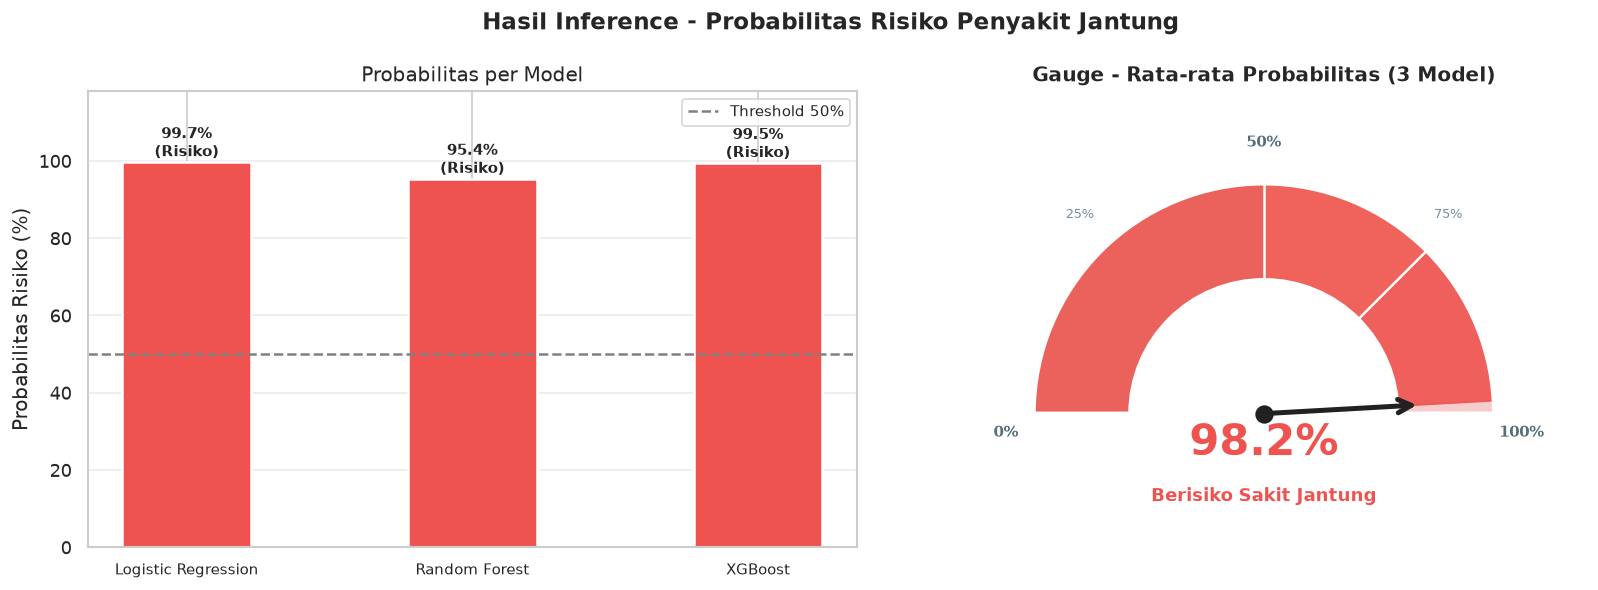

In [27]:
# Visualisasi Probabilitas Risiko
model_names_inf = list(inference_results.keys())
probs           = [inference_results[n]['prob'] * 100 for n in model_names_inf]
preds           = [inference_results[n]['pred'] for n in model_names_inf]
bar_colors      = ['#EF5350' if p == 1 else '#66BB6A' for p in preds]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hasil Inference - Probabilitas Risiko Penyakit Jantung',
             fontsize=14, fontweight='bold')

# Panel Kiri: Bar Chart per Model
bars = axes[0].bar(model_names_inf, probs,
                   color=bar_colors, edgecolor='white', linewidth=1.5, width=0.45)
axes[0].axhline(50, color='gray', linestyle='--', lw=1.5, label='Threshold 50%')

for bar, v, pred in zip(bars, probs, preds):
    status = 'Risiko' if pred == 1 else 'Aman'
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{v:.1f}%\n({status})',
        ha='center', fontsize=9, fontweight='bold'
    )

axes[0].set_ylim(0, 118)
axes[0].set_ylabel('Probabilitas Risiko (%)')
axes[0].set_title('Probabilitas per Model')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.4)
axes[0].tick_params(axis='x', labelsize=9)

# Panel Kanan: Gauge Chart menggunakan Wedge patch
#
# Konvensi sudut (matplotlib, CCW dari sumbu X kanan):
#   Kiri  = 180 deg = 0%  risiko
#   Atas  =  90 deg = 50% risiko
#   Kanan =   0 deg = 100% risiko
#
# Rumus jarum: needle_deg = 180 * (1 - avg_prob)
#   prob=0.00 -> 180 deg (kiri, aman)
#   prob=0.50 ->  90 deg (atas, sedang)
#   prob=1.00 ->   0 deg (kanan, berisiko)
#
gauge_col   = '#EF5350' if avg_prob >= 0.5 else '#66BB6A'
outer_r     = 1.0
donut_width = 0.42
needle_deg  = 180.0 * (1.0 - avg_prob)
needle_rad  = np.deg2rad(needle_deg)

ax2 = axes[1]

# Zona warna latar (hijau=aman, kuning=sedang, merah=berisiko)
ax2.add_patch(Wedge((0,0), outer_r,  90, 180, width=donut_width, color='#A5D6A7', alpha=0.5, zorder=1))
ax2.add_patch(Wedge((0,0), outer_r,  45,  90, width=donut_width, color='#FFF176', alpha=0.5, zorder=1))
ax2.add_patch(Wedge((0,0), outer_r,   0,  45, width=donut_width, color='#EF9A9A', alpha=0.5, zorder=1))

# Isi warna utama: dari posisi jarum ke 180 deg
# Semakin besar avg_prob -> needle_deg kecil -> isian dari kanan ke kiri semakin lebar
if needle_deg < 179.99:
    ax2.add_patch(Wedge((0,0), outer_r, needle_deg, 180,
                        width=donut_width, color=gauge_col, alpha=0.90, zorder=2))

# Border outline
ax2.add_patch(Wedge((0,0), outer_r, 0, 180, width=donut_width,
                    fill=False, edgecolor='white', linewidth=2.5, zorder=3))

# Garis pemisah zona
for deg in [45, 90]:
    rad = np.deg2rad(deg)
    ax2.plot(
        [np.cos(rad)*(outer_r-donut_width), np.cos(rad)*outer_r],
        [np.sin(rad)*(outer_r-donut_width), np.sin(rad)*outer_r],
        color='white', lw=1.5, zorder=3
    )

# Jarum penunjuk
nx = np.cos(needle_rad) * 0.68
ny = np.sin(needle_rad) * 0.68
ax2.annotate(
    '', xy=(nx, ny), xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='#212121', lw=3.0, mutation_scale=20)
)
ax2.plot(0, 0, 'o', color='#212121', ms=10, zorder=5)

# Teks persentase & verdict
ax2.text(0, -0.18, f'{avg_prob*100:.1f}%',
         ha='center', fontsize=26, fontweight='bold', color=gauge_col)
verdict_txt = 'Tidak Berisiko' if final_vote == 0 else 'Berisiko Sakit Jantung'
ax2.text(0, -0.38, verdict_txt,
         ha='center', fontsize=11, color=gauge_col, fontweight='bold')

# Label skala
ax2.text(-1.12, -0.10, '0%',   fontsize=9, ha='center', color='#546E7A', fontweight='bold')
ax2.text( 1.12, -0.10, '100%', fontsize=9, ha='center', color='#546E7A', fontweight='bold')
ax2.text( 0,    1.16,  '50%',  fontsize=9, ha='center', color='#546E7A', fontweight='bold')
ax2.text(-0.80,  0.85, '25%',  fontsize=8, ha='center', color='#78909C')
ax2.text( 0.80,  0.85, '75%',  fontsize=8, ha='center', color='#78909C')

ax2.set_xlim(-1.4, 1.4)
ax2.set_ylim(-0.58, 1.40)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Gauge - Rata-rata Probabilitas (3 Model)', fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
# Tabel Ringkasan Inference
rows = [
    {
        'Model'              : name,
        'Prediksi'           : 'Risiko' if v['pred'] == 1 else 'Aman',
        'Prob. Risiko (%)'   : f"{v['prob']*100:.2f}%",
        'Prob. Aman   (%)'   : f"{(1 - v['prob'])*100:.2f}%"
    }
    for name, v in inference_results.items()
]
rows.append({
    'Model'              : 'Voting Mayoritas',
    'Prediksi'           : 'Risiko' if final_vote == 1 else 'Aman',
    'Prob. Risiko (%)'   : f'{avg_prob*100:.2f}%',
    'Prob. Aman   (%)'   : f'{(1-avg_prob)*100:.2f}%'
})

inf_summary = pd.DataFrame(rows).set_index('Model')

print('=' * 65)
print('RINGKASAN INFERENCE PASIEN BARU')
print('=' * 65)
print(inf_summary.to_string())
print('=' * 65)
print()
print('Catatan: Prediksi ini bersifat INDIKATIF dan bukan pengganti')
print('         diagnosis medis dari tenaga kesehatan profesional.')
print('=' * 65)

RINGKASAN INFERENCE PASIEN BARU
                    Prediksi Prob. Risiko (%) Prob. Aman   (%)
Model                                                         
Logistic Regression   Risiko           99.73%            0.27%
Random Forest         Risiko           95.41%            4.59%
XGBoost               Risiko           99.50%            0.50%
Voting Mayoritas      Risiko           98.21%            1.79%

Catatan: Prediksi ini bersifat INDIKATIF dan bukan pengganti
         diagnosis medis dari tenaga kesehatan profesional.


## 8. Simpan Knowledge Model

Menyimpan model yang telah dilatih beserta artefak pendukung ke folder `model/`,
agar dapat digunakan kembali untuk inferensi tanpa perlu melatih ulang.

**File yang disimpan:**
| File | Isi |
|---|---|
| `model_logistic_regression.pkl` | Logistic Regression |
| `model_random_forest.pkl` | Random Forest |
| `model_xgboost.pkl` | XGBoost |
| `scaler.pkl` | StandardScaler (untuk Logistic Regression) |
| `feature_columns.pkl` | Daftar & urutan kolom fitur saat training |
| `model_metadata.json` | Metadata & metrik evaluasi semua model |

In [29]:
import joblib
import json as _json
import os
from datetime import datetime

# Buat folder model/ jika belum ada
MODEL_DIR = os.path.join(os.getcwd(), 'model')
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Folder model : {MODEL_DIR}')

# Simpan setiap model
model_filenames = {
    'Logistic Regression' : 'model_logistic_regression.pkl',
    'Random Forest'       : 'model_random_forest.pkl',
    'XGBoost'             : 'model_xgboost.pkl',
}

print('\nMenyimpan model...')
for name, filename in model_filenames.items():
    path = os.path.join(MODEL_DIR, filename)
    joblib.dump(results[name]['model'], path)
    size_kb = os.path.getsize(path) / 1024
    print(f'   {filename:<40} ({size_kb:.1f} KB)')

# Simpan scaler
scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'   scaler.pkl                               ({os.path.getsize(scaler_path)/1024:.1f} KB)')

# Simpan feature columns
feat_path = os.path.join(MODEL_DIR, 'feature_columns.pkl')
joblib.dump(list(X.columns), feat_path)
print(f'   feature_columns.pkl                      ({os.path.getsize(feat_path)/1024:.1f} KB)')

# Simpan metadata & metrik evaluasi sebagai JSON
metadata = {
    'saved_at'       : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset'        : 'heart_disease_risk_2026.csv',
    'n_samples'      : int(len(X)),
    'n_features'     : int(X.shape[1]),
    'feature_columns': list(X.columns),
    'test_size'      : 0.2,
    'random_state'   : 42,
    'models'         : {
        name: {
            'file'      : model_filenames[name],
            'accuracy'  : round(float(r['accuracy']),  4),
            'precision' : round(float(r['precision']), 4),
            'recall'    : round(float(r['recall']),    4),
            'f1'        : round(float(r['f1']),        4),
            'roc_auc'   : round(float(r['roc_auc']),   4),
            'cv_mean'   : round(float(r['cv_mean']),   4),
            'cv_std'    : round(float(r['cv_std']),    4),
        }
        for name, r in results.items()
    }
}

meta_path = os.path.join(MODEL_DIR, 'model_metadata.json')
with open(meta_path, 'w', encoding='utf-8') as _f:
    _json.dump(metadata, _f, ensure_ascii=False, indent=2)
print(f'   model_metadata.json                      ({os.path.getsize(meta_path)/1024:.1f} KB)')

# Tampilkan ringkasan
print('\n' + '=' * 60)
print('RINGKASAN FILE YANG TERSIMPAN DI FOLDER model/')
print('=' * 60)
total_size = 0
for fname in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, fname)
    sz = os.path.getsize(fpath)
    total_size += sz
    print(f'   {fname:<42} {sz/1024:>8.1f} KB')
print('-' * 60)
print(f'   Total                                      {total_size/1024:>8.1f} KB')
print('=' * 60)
print(f'\nSemua artefak berhasil disimpan ke: {MODEL_DIR}')

Folder model : c:\Users\admin\Documents\Portofolio\Heart Disease Risk 2026\Prediction\model

Menyimpan model...
   model_logistic_regression.pkl            (1.1 KB)
   model_random_forest.pkl                  (16851.4 KB)
   model_xgboost.pkl                        (663.8 KB)
   scaler.pkl                               (2.0 KB)
   feature_columns.pkl                      (0.5 KB)
   model_metadata.json                      (1.6 KB)

RINGKASAN FILE YANG TERSIMPAN DI FOLDER model/
   feature_columns.pkl                             0.5 KB
   model_logistic_regression.pkl                   1.1 KB
   model_metadata.json                             1.6 KB
   model_random_forest.pkl                     16851.4 KB
   model_xgboost.pkl                             663.8 KB
   scaler.pkl                                      2.0 KB
------------------------------------------------------------
   Total                                       17520.4 KB

Semua artefak berhasil disimpan ke: c:\Users\adm

In [30]:
# Demo: Load model & lakukan prediksi ulang untuk verifikasi
print('Demo - Memuat model dari folder model/')
print('=' * 60)

loaded_models = {
    'Logistic Regression' : joblib.load(os.path.join(MODEL_DIR, 'model_logistic_regression.pkl')),
    'Random Forest'       : joblib.load(os.path.join(MODEL_DIR, 'model_random_forest.pkl')),
    'XGBoost'             : joblib.load(os.path.join(MODEL_DIR, 'model_xgboost.pkl')),
}
loaded_scaler  = joblib.load(os.path.join(MODEL_DIR, 'scaler.pkl'))
loaded_columns = joblib.load(os.path.join(MODEL_DIR, 'feature_columns.pkl'))

print('   Semua model & artefak berhasil dimuat.')
print(f'   Jumlah fitur : {len(loaded_columns)}')
print(f'   Fitur sample : {loaded_columns[:5]} ...')

print('\nVerifikasi konsistensi prediksi...')
for name, model_obj in loaded_models.items():
    X_inp = X_test_scaled if name == 'Logistic Regression' else X_test
    y_hat = model_obj.predict(X_inp)
    acc   = accuracy_score(y_test, y_hat)
    match = 'SAMA' if abs(acc - results[name]['accuracy']) < 1e-9 else 'BERBEDA'
    print(f'   {name:<25} Accuracy: {acc:.4f}  [{match}]')

print('\nModel berhasil dimuat dan terverifikasi!')

Demo - Memuat model dari folder model/
   Semua model & artefak berhasil dimuat.
   Jumlah fitur : 28
   Fitur sample : ['age', 'sex', 'resting_bp_systolic', 'resting_bp_diastolic', 'cholesterol_total'] ...

Verifikasi konsistensi prediksi...
   Logistic Regression       Accuracy: 0.8972  [SAMA]
   Random Forest             Accuracy: 0.8811  [SAMA]
   XGBoost                   Accuracy: 0.8878  [SAMA]

Model berhasil dimuat dan terverifikasi!
